# Modeling

**Nina Haide**

## Introduction

This project aims at conducting an
unsupervised machine learning analysis of AI job postings across the DACH region
(Germany, Austria and Switzerland). The dataset was collected via the Adzuna Jobs
API, extended here with a
description enrichment step to extract skill profiles from full job posting pages.
The core analytical question is whether natural skill-based role archetypes exist
in the DACH AI job market that diverge from the official job titles assigned by
employers.
The analysis covers data preparation, binary skill matrix construction, K-Means
clustering and qualitative cluster interpretation.

## Data Set

The dataset was created using a custom script built on the Adzuna
Jobs API, collecting AI job postings across Germany, Austria and
Switzerland using 31 targeted search queries across five role categories. Initial
collection produced 485 unique postings, which were subsequently enriched by
fetching full job descriptions from source pages to improve skill extraction
coverage. The final modeling dataset comprises 304 job postings with at least one
detected skill, stored across two CSV files: `adzuna_ai_jobs_dach_enriched.csv`
and `adzuna_ai_skills_dach_enriched.csv`.

In [1]:
 import numpy as np
 import pandas as pd
 import matplotlib.pyplot as plt
 import seaborn as sns

In [2]:
from sklearn.preprocessing import MultiLabelBinarizer  
from sklearn.cluster import KMeans                      
from sklearn.metrics import silhouette_score            
from sklearn.decomposition import PCA                   

In [3]:
 jobs = pd.read_csv("adzuna_ai_jobs_dach.csv")
 jobs.head()

,id,title,company,location,country,category,contract_type,contract_time,salary_min,salary_max,date_posted,description,role_category,search_query,url
0,de_5708353171,Senior Engineer Machine Learning / AI (w/m/d),HUK-COBURG Versicherungsgruppe,"Coburg, Coburg (Kreis)",Germany,IT-Stellen,NaN,NaN,NaN,NaN,2026-04-23,"Hallo, lass uns WIR sagen! Wir - die HUK-COBUR...",AI_Engineering,AI Engineer Machine Learning,https://www.adzuna.de/land/ad/5708353171?se=fG...
1,de_5722278756,AI & Machine Learning Engineer (all genders),SThree Germany,"Hausen, Frankfurt am Main",Germany,IT-Stellen,permanent,full_time,80000.0,95000.0,2026-05-08,AI & Machine Learning Engineer (all genders) U...,AI_Engineering,AI Engineer Machine Learning,https://www.adzuna.de/details/5722278756?utm_m...
2,de_5680334179,Digital Process Engineer – AI & Automation (KI...,GPE MedTech Systeme GmbH,"Dassow, Nordwestmecklenburg (Kreis)",Germany,Beraterstellen,NaN,NaN,NaN,NaN,2026-03-27,Digital Process Engineer – AI & Automation (KI...,AI_Engineering,AI Engineer Machine Learning,https://www.adzuna.de/details/5680334179?utm_m...
3,de_5418313407,Senior AI / Machine Learning Engineer – Enterp...,Nortal,Deutschland,Germany,IT-Stellen,permanent,full_time,NaN,NaN,2025-09-27,Wir bei Nortal unterstützen den öffentlichen S...,AI_Engineering,AI Engineer Machine Learning,https://www.adzuna.de/details/5418313407?utm_m...
4,de_5698582069,AI & Machine Learning Engineer – Sensor Fusion...,Collective.work,"Altstadt-Lehel, München",Germany,Sonstige/Allgemeine Stellen,permanent,full_time,65000.0,105000.0,2026-04-14,Job description Salary: 65-105k€ (Annuel) AI &...,AI_Engineering,AI Engineer Machine Learning,https://www.adzuna.de/details/5698582069?utm_m...


In [4]:
 skills = pd.read_csv("adzuna_ai_skills_dach.csv")
 skills.head()

,job_id,skill,country,role_category
0,de_5722278756,git,Germany,AI_Engineering
1,de_5722278756,machine learning,Germany,AI_Engineering
2,de_5722278756,rag,Germany,AI_Engineering
3,de_5680334179,git,Germany,AI_Engineering
4,de_5680334179,machine learning,Germany,AI_Engineering


In [5]:
print("Jobs shape:", jobs.shape)
print("Skills shape:", skills.shape)
print("\nJob columns:", jobs.columns.tolist())

Jobs shape: (485, 15)
Skills shape: (378, 4)

Job columns: ['id', 'title', 'company', 'location', 'country', 'category', 'contract_type', 'contract_time', 'salary_min', 'salary_max', 'date_posted', 'description', 'role_category', 'search_query', 'url']


In [6]:
print("\nMissing values (jobs):")
print(jobs.isnull().sum())


Missing values (jobs):
id                 0
title              0
company            1
location           0
country            0
category           0
contract_type    418
contract_time    269
salary_min       457
salary_max       457
date_posted        0
description        0
role_category      0
search_query       0
url                0
dtype: int64


In [7]:
jobs_with_skills = skills["job_id"].nunique()
print(f"\nJobs with ≥1 skill: {jobs_with_skills} / {len(jobs)}")
print(f"Jobs with 0 skills: {len(jobs) - jobs_with_skills}")


Jobs with ≥1 skill: 252 / 485
Jobs with 0 skills: 233


In [8]:
print("\nSkills per job stats:")
print(skills.groupby("job_id")["skill"].count().describe())


Skills per job stats:
count    252.000000
mean       1.500000
std        0.894873
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        5.000000
Name: skill, dtype: float64


In [9]:
print("\nTop 20 skills:")
print(skills["skill"].value_counts().head(20))


Top 20 skills:
skill
git                       87
rag                       54
machine learning          32
sap                       26
scala                     25
generative ai             22
agile                     17
api                       16
rpa                       16
llm                       14
computer vision           14
aws                       11
deep learning              8
spark                      5
azure                      5
python                     4
kubernetes                 3
reinforcement learning     2
databricks                 2
mlops                      2
Name: count, dtype: int64


The initial dataset collected via fetch_ai_jobs_and_skills.py contains 485 unique job postings across the DACH region. The Adzuna API caps description length at approximately 500 characters, which limited skill extraction to only 252 of 485 jobs (52%) with a mean of 1.5 skills per job — too sparse for meaningful clustering. To address this, fetch_ai_jobs_and_skills_enriched.py follows each posting's redirect URL, fetches the full job page and re-runs skill extraction on the complete text, saving the results to adzuna_ai_jobs_dach_enriched.csv and adzuna_ai_skills_dach_enriched.csv.

In [10]:
jobs_enriched = pd.read_csv("adzuna_ai_jobs_dach_enriched.csv")
skills_enriched = pd.read_csv("adzuna_ai_skills_dach_enriched.csv")

In [11]:
print("Jobs shape:", jobs_enriched.shape)
print("Skills shape:", skills_enriched.shape)

Jobs shape: (485, 17)
Skills shape: (1470, 4)


In [12]:
print("Description length distribution:")
print(jobs_enriched["description_length"].describe())
print(f"\nFetch failed (<=500 chars): {(jobs_enriched['description_length'] <= 500).sum()}")
print(f"Fetch succeeded (>500 chars): {(jobs_enriched['description_length'] > 500).sum()}")

Description length distribution:
count     485.000000
mean     3402.540206
std      2034.167858
min       500.000000
25%       500.000000
50%      4974.000000
75%      5000.000000
max      5000.000000
Name: description_length, dtype: float64

Fetch failed (<=500 chars): 155
Fetch succeeded (>500 chars): 330


In [13]:
jobs_with_skills = skills_enriched["job_id"].nunique()
print(f"\nJobs with ≥1 skill: {jobs_with_skills} / {len(jobs_enriched)}")
print(f"Jobs with 0 skills: {len(jobs_enriched) - jobs_with_skills}")


Jobs with ≥1 skill: 304 / 485
Jobs with 0 skills: 181


In [14]:
print("\nTop 25 skills:")
print(skills_enriched["skill"].value_counts().head(25))


Top 25 skills:
skill
python              123
machine learning    114
scala               101
generative ai        84
agile                69
aws                  65
llm                  62
ci/cd                58
azure                56
kubernetes           50
docker               49
mlops                43
pytorch              43
gcp                  41
rpa                  38
api                  37
sql                  36
computer vision      33
sap                  32
deep learning        28
tensorflow           26
nlp                  25
statistics           25
git                  25
spark                23
Name: count, dtype: int64


## Data Preparation and Preprocessing

The goal of preprocessing is to transform the raw job postings and skills data
into a binary skill matrix suitable for K-Means clustering — one row per job,
one column per skill, with a value of 1 if the skill was detected in that
posting and 0 if not.

In [15]:
# Drop jobs with zero skills detected have no signal for clustering
jobs_with_skills = skills_enriched["job_id"].nunique()
valid_ids = skills_enriched["job_id"].unique()

jobs_model = jobs_enriched[jobs_enriched["id"].isin(valid_ids)].copy()
print(f"Jobs retained for modeling: {len(jobs_model)} / {len(jobs_enriched)}")
print(f"Jobs dropped (no skills detected): {len(jobs_enriched) - len(jobs_model)}")

Jobs retained for modeling: 304 / 485
Jobs dropped (no skills detected): 181


The columns `contract_type`, `contract_time`, `salary_min`, and `salary_max`
have high rates of missing values (86–94%). Since these fields are not used
as clustering features, no imputation is required. The one missing `company`
entry is retained as-is. The only meaningful action is dropping jobs with no
detected skills, as these provide no information for the clustering algorithm.

### Feature Engineering — Binary Skill Matrix

Each job posting is represented as a binary vector where each dimension
corresponds to one skill in the taxonomy. A value of 1 indicates the skill
was detected in the job description, 0 indicates it was not. This encoding
is appropriate for categorical presence/absence data and is the standard
input format for K-Means clustering on skill profiles.

No scaling or normalisation is applied — binary features are already on a
uniform [0, 1] scale and scaling would distort the equal weighting of skills.

In [16]:
from sklearn.preprocessing import MultiLabelBinarizer

# Group skills per job as a list
job_skills = (skills_enriched.groupby("job_id")["skill"]
              .apply(list)
              .reset_index()
              .rename(columns={"skill": "skills"}))

# Binarize — one column per skill
mlb = MultiLabelBinarizer()
skill_matrix = mlb.fit_transform(job_skills["skills"])
skill_matrix_df = pd.DataFrame(skill_matrix, 
                                columns=mlb.classes_, 
                                index=job_skills["job_id"])

print(f"Skill matrix shape: {skill_matrix_df.shape}")
print(f"Skills (features): {list(mlb.classes_)}")
skill_matrix_df.head()

Skill matrix shape: (304, 45)
Skills (features): ['agile', 'airflow', 'api', 'aws', 'azure', 'c++', 'ci/cd', 'computer vision', 'databricks', 'dbt', 'deep learning', 'docker', 'gcp', 'generative ai', 'git', 'hugging face', 'java', 'julia', 'kafka', 'keras', 'kubernetes', 'llm', 'machine learning', 'mlflow', 'mlops', 'nlp', 'numpy', 'pandas', 'power bi', 'prompt engineering', 'python', 'pytorch', 'r', 'rag', 'reinforcement learning', 'rpa', 'sap', 'scala', 'scikit-learn', 'snowflake', 'spark', 'sql', 'statistics', 'tableau', 'tensorflow']


,agile,airflow,api,aws,azure,c++,ci/cd,computer vision,databricks,dbt,...,rpa,sap,scala,scikit-learn,snowflake,spark,sql,statistics,tableau,tensorflow
job_id,,,,,,,,,,,,,,,,,,,,,
at_5234740833,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
at_5516032105,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
at_5620870356,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
at_5656789007,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
at_5685550187,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Feature Selection

All detected skills are retained as features. The metadata columns `title`,
`country`, and `role_category` are attached to the matrix for interpretability
but excluded from the clustering algorithm. This allows to compare the
data-driven clusters against the human-assigned role categories after
clustering, which is the core analytical question.

In [18]:
# Attach country and role_category for post-clustering interpretation
# These are NOT used as clustering features — only for labelling results
meta = jobs_model.set_index("id")[["title", "country", "role_category"]]
skill_matrix_df = skill_matrix_df.join(meta)

print("Final dataset shape:", skill_matrix_df.shape)
print("\nRole category distribution:")
print(skill_matrix_df["role_category"].value_counts())
print("\nCountry distribution:")
print(skill_matrix_df["country"].value_counts())

Final dataset shape: (304, 48)

Role category distribution:
role_category
AI_Engineering    119
AI_PM              70
Data_Analytics     60
AI_Integration     46
AI_Consulting       9
Name: count, dtype: int64

Country distribution:
country
Germany        275
Switzerland     17
Austria         12
Name: count, dtype: int64


## Model Selection and Training

This is an unsupervised learning task. The goal is to discover natural groupings
of job postings based on their skill profiles, without using the human-assigned
role categories as labels. K-Means clustering is selected because it is
well-suited to binary feature matrices, produces interpretable cluster centroids
that reveal the dominant skills per group and scales efficiently to the dataset size.

In [19]:
# Define feature columns (skills only) and metadata columns
meta_cols = ["title", "country", "role_category"]
feature_cols = [col for col in skill_matrix_df.columns if col not in meta_cols]

X = skill_matrix_df[feature_cols].values
print(f"Feature matrix shape: {X.shape}")
print(f"Number of skills (features): {len(feature_cols)}")

Feature matrix shape: (304, 45)
Number of skills (features): 45


### Choosing the Number of Clusters — Elbow Method

K-Means requires the number of clusters k to be specified in advance. The elbow
method plots inertia (within-cluster sum of squared distances) across a range
of k values. The optimal k is identified at the point where adding more clusters
yields diminishing returns — the "elbow" in the curve.

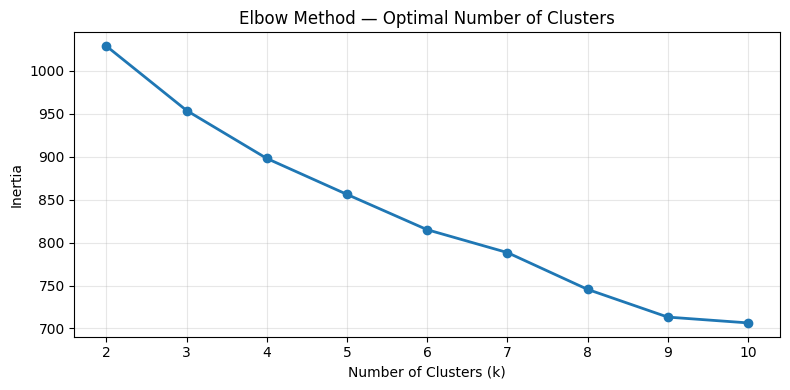

In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker="o", linewidth=2)
plt.title("Elbow Method — Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("viz_elbow.png", dpi=150)
plt.show()

### Training the Final Model

Based on the elbow plot, k is selected at the point where inertia stops
decreasing sharply. The model is trained with `n_init=10` meaning K-Means
is run 10 times with different initialisations and the best result is kept,
reducing sensitivity to random starting positions.

In [21]:
# Set k based on elbow plot result

K = 5

km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
km_final.fit(X)

# Attach cluster labels to the dataframe
skill_matrix_df["cluster"] = km_final.labels_

print(f"K-Means trained with k={K}")
print(f"\nCluster sizes:")
print(skill_matrix_df["cluster"].value_counts().sort_index())

K-Means trained with k=5

Cluster sizes:
cluster
0    116
1     38
2     35
3     76
4     39
Name: count, dtype: int64


### Cluster Profiles

The centroid of each cluster represents the average skill profile of jobs
assigned to that group. The skills with the highest centroid weights are
the defining characteristics of that cluster - effectively describing what
kind of role archetype the cluster represents.

In [22]:
# Top 5 skills per cluster by centroid weight

centroids = pd.DataFrame(km_final.cluster_centers_, 
                          columns=feature_cols)

print("Top 5 skills per cluster:\n")
for i in range(K):
    top_skills = centroids.iloc[i].sort_values(ascending=False).head(5)
    print(f"Cluster {i}: {', '.join(top_skills.index.tolist())}")

Top 5 skills per cluster:

Cluster 0: agile, machine learning, python, sql, git
Cluster 1: azure, python, gcp, aws, docker
Cluster 2: python, machine learning, generative ai, kubernetes, mlops
Cluster 3: scala, rpa, python, generative ai, aws
Cluster 4: machine learning, python, computer vision, deep learning, generative ai


## Model Evaluation

For unsupervised clustering there is no ground truth label to compare against.
Evaluation combines a quantitative metric (silhouette score) with qualitative
interpretation of the cluster profiles and a comparison against the
human-assigned role categories.

In [23]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, km_final.labels_)
print(f"Silhouette Score (k={K}): {score:.4f}")
print("""
Interpretation:
  > 0.5  — strong cluster structure
  0.2–0.5 — reasonable structure
  < 0.2  — weak or overlapping clusters
""")

Silhouette Score (k=5): 0.0895

Interpretation:
  > 0.5  — strong cluster structure
  0.2–0.5 — reasonable structure
  < 0.2  — weak or overlapping clusters



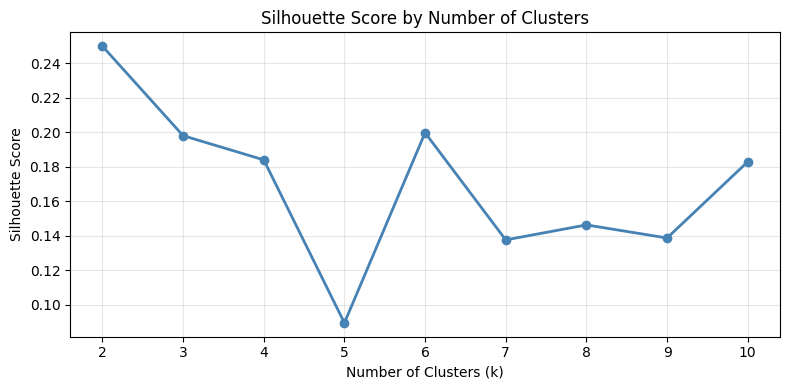

In [24]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

plt.figure(figsize=(8, 4))
plt.plot(k_range, sil_scores, marker="o", linewidth=2, color="steelblue")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("viz_silhouette.png", dpi=150)
plt.show()

### Cluster Visualisation — PCA Projection

Since the skill matrix has many dimensions, Principal Component Analysis (PCA)
is used to reduce it to two dimensions for visualisation. This does not affect
the clustering - it is applied only to plot the results in 2D space.

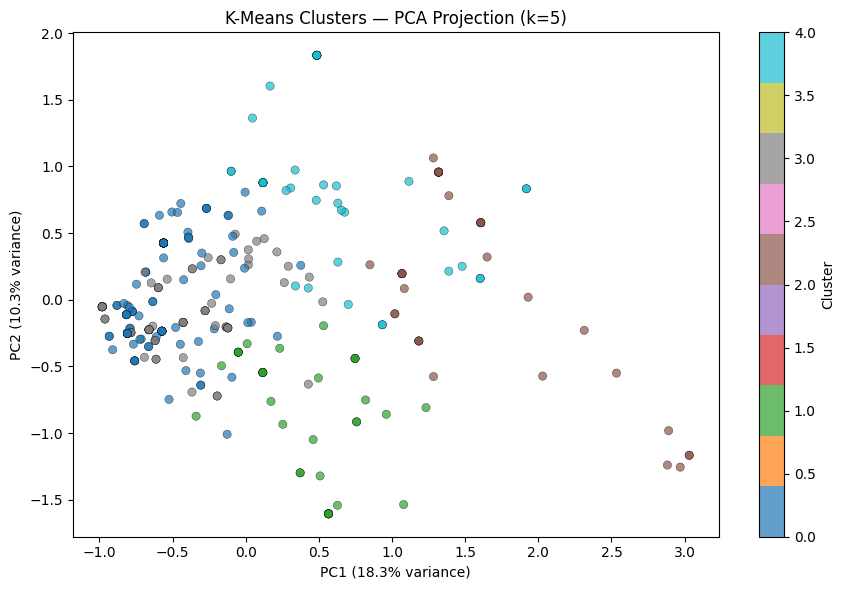

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=skill_matrix_df["cluster"],
                      cmap="tab10", alpha=0.7, edgecolors="k", linewidths=0.3)
plt.colorbar(scatter, label="Cluster")
plt.title(f"K-Means Clusters — PCA Projection (k={K})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()
plt.savefig("viz_clusters_pca.png", dpi=150)
plt.show()

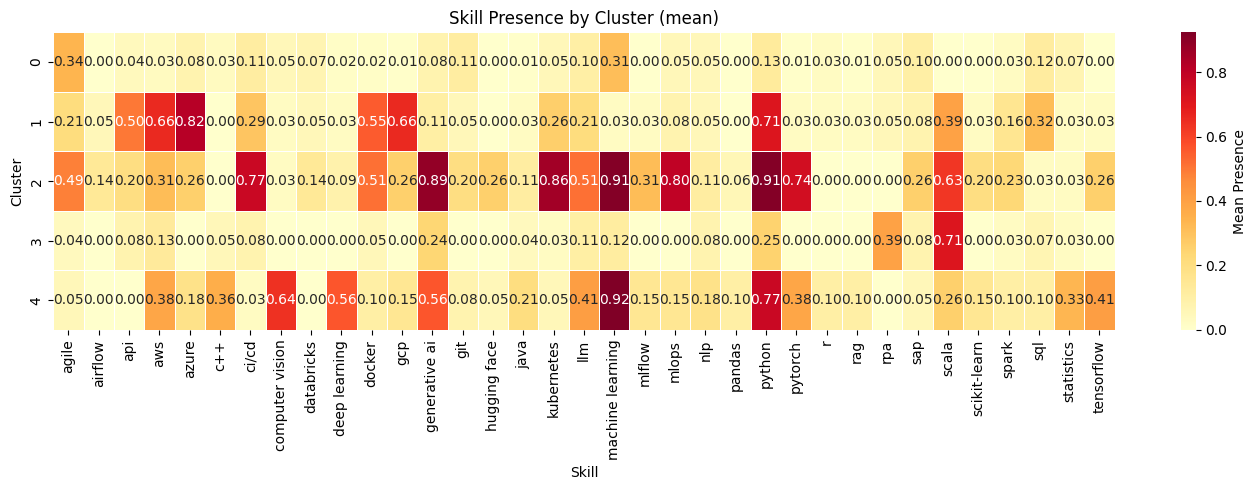

In [26]:
import seaborn as sns

# Mean skill presence per cluster
heatmap_data = skill_matrix_df.groupby("cluster")[feature_cols].mean()

# Keep only skills with meaningful presence in at least one cluster
active_skills = heatmap_data.columns[heatmap_data.max() > 0.1]
heatmap_data = heatmap_data[active_skills]

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Mean Presence"})
plt.title("Skill Presence by Cluster (mean)")
plt.xlabel("Skill")
plt.ylabel("Cluster")
plt.tight_layout()
plt.savefig("viz_skill_heatmap.png", dpi=150)
plt.show()

In [27]:
# Cross-tabulation: cluster vs human-assigned role category
crosstab = pd.crosstab(skill_matrix_df["cluster"],
                       skill_matrix_df["role_category"],
                       normalize="index").round(2)
print("Cluster composition by role category (row %):")
print(crosstab)

# Name clusters based on dominant skills
print("\nDominant skills per cluster:")
for i in range(K):
    top = centroids.iloc[i].sort_values(ascending=False).head(5)
    size = (skill_matrix_df["cluster"] == i).sum()
    print(f"\nCluster {i} (n={size}):")
    print(f"  Skills : {', '.join(top.index.tolist())}")
    dominant_role = crosstab.loc[i].idxmax()
    print(f"  Dominant role category: {dominant_role} ({crosstab.loc[i].max()*100:.0f}%)")

Cluster composition by role category (row %):
role_category  AI_Consulting  AI_Engineering  AI_Integration  AI_PM  \
cluster                                                               
0                       0.03            0.27            0.07   0.22   
1                       0.03            0.45            0.05   0.29   
2                       0.00            0.71            0.14   0.11   
3                       0.05            0.16            0.41   0.36   
4                       0.00            0.87            0.00   0.05   

role_category  Data_Analytics  
cluster                        
0                        0.41  
1                        0.18  
2                        0.03  
3                        0.03  
4                        0.08  

Dominant skills per cluster:

Cluster 0 (n=116):
  Skills : agile, machine learning, python, sql, git
  Dominant role category: Data_Analytics (41%)

Cluster 1 (n=38):
  Skills : azure, python, gcp, aws, docker
  Dominant role cate

### Evaluation Summary

The silhouette score provides a quantitative measure of cluster separation.
The PCA plot shows the spatial distribution of clusters in reduced dimensions,
while the heatmap reveals which skills define each archetype. The cross-tabulation
compares the data-driven clusters against the human-assigned role categories -
strong alignment suggests the skill profiles reflect real role boundaries, while
misalignment reveals that some roles share skill sets more than their titles suggest
or that the market has evolved beyond traditional categorisations.

## Conclusion

In this project an unsupervised learning problem was addressed, the clustering of DACH AI job
postings by skill profile to discover natural role archetypes beyond official job
titles. K-Means clustering with k=5 was selected as the model, using a binary
skill matrix as input where each dimension represents the presence or absence of
a detected skill in a job description. The model identified five distinct clusters
— Data & Analytics Generalist, Cloud ML Engineer, MLOps & GenAI Engineer, AI
Automation & Integration and Deep Learning & AI Research - with AI_Engineering
dominating three of the five clusters at rates between 45% and 87%. The silhouette
score was low, which is expected for real-world job market data where role skill
profiles genuinely overlap, particularly between consulting, PM and engineering
roles in the DACH region. The main data challenge was the Adzuna API's 500-character
description limit, which required a secondary enrichment step to fetch full job
descriptions from source pages - 155 of 485 postings (32%) could not be enriched
due to JavaScript-rendered pages, leaving 304 jobs in the final modeling dataset.

In [28]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
